# Optimización de hiperparámetros: comparación de los cuatro métodos

Este capítulo responde la pregunta de la Sección 3 de la guía: **¿qué método de optimización
encuentra mejores configuraciones por unidad de presupuesto computacional, y por qué?** Tiene
cuatro partes:

1. **Comparación sobre el estudio completo** (140 combinaciones x 5 pliegues): métricas del bucle
   externo, tiempos, evaluaciones y curvas de desempeño en cualquier momento (*anytime*), con
   pruebas estadísticas sobre esas curvas.
2. **Estudio dedicado de convergencia**: XGBoost con un presupuesto mayor (50 evaluaciones) y tres
   semillas por método, para estudiar convergencia y estabilidad frente a la semilla.
3. **Detalle de los métodos Bayesiano y Genético**: modelo sustituto y función de adquisición del
   TPE; operadores, elitismo y diversidad genética del genético.
4. **Successive Halving** como técnica multi-fidelidad, y una verificación numérica de que el
   preprocesamiento en caché equivale a un `Pipeline` reajustado en cada evaluación.

Todos los experimentos nuevos de este capítulo se guardan en `resultados/estudios/` y se saltan si
ya existen: el notebook puede re-ejecutarse sin repetir cálculos.

In [1]:
# --- preambulo comun: localiza la raiz del libro y carga el paquete src ------
import os, sys, warnings
from pathlib import Path
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "_config.yml").is_file() and (p / "src").is_dir())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
# los procesos paralelos de joblib (loky) tambien deben encontrar `src`
os.environ["PYTHONPATH"] = str(RAIZ) + os.pathsep + os.environ.get("PYTHONPATH", "")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src import config, graficos
config.fijar_semillas()
config.crear_directorios()
graficos.estilo()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
print(config.resumen())

Raiz del proyecto     : entregable3
Modo prueba           : False
Semilla               : 42
CV anidada            : 5 externos x 3 internos
Evaluaciones/optimiz. : 20
Nucleos               : 11   paralelo interno: True
XGBoost               : device='cuda'
Random Forest         : xgbrf   KNN: torch


In [2]:
import json, time, traceback
import joblib
from scipy import stats
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from src import experimento as ex, espacios, modelos as mod, optimizadores as opt
from src import estadistica as est_, datos, preprocesamiento as prep
from src.graficos import COLOR_OPT

pliegues, maestra = ex.consolidar()
registros = ex.leer_corridas()
METODOS = list(opt.OPTIMIZADORES)
print(f"Unidades disponibles: {len(registros)}")

Unidades disponibles: 700


## 1. Los cuatro métodos

| Método | Idea | Qué aprende de las evaluaciones previas |
|---|---|---|
| Grid Search | Recorre una rejilla fija de niveles equiespaciados (en escala log cuando corresponde) | Nada |
| Random Search | Muestrea configuraciones independientes del espacio | Nada; pero no desperdicia evaluaciones en dimensiones irrelevantes (Bergstra y Bengio, 2012) |
| Bayesiana (Optuna, TPE) | Ajusta un modelo sustituto de la relación hiperparámetros → AUC y propone donde la función de adquisición es máxima | Todo el historial |
| Genética (DEAP) | Evoluciona una población por selección, cruce y mutación | La población actual (memoria implícita) |

**Modelo sustituto y función de adquisición (Bayesiana).** Optuna no usa un proceso gaussiano sino
un *Tree-structured Parzen Estimator* (Bergstra et al., 2011). En lugar de modelar p(y | x), modela
dos densidades sobre los hiperparámetros: l(x), estimada con las configuraciones del mejor cuantil γ
(las "buenas"), y g(x), con el resto. La función de adquisición es la **Mejora Esperada (EI)**; bajo
el TPE, maximizar EI equivale a maximizar el cociente l(x)/g(x), y Optuna lo hace evaluando 24
candidatos muestreados de l(x). El balance exploración-explotación lo gobiernan tres elementos: las
primeras `max(3, presupuesto/4)` evaluaciones son aleatorias (exploración pura, 5 de 20 aquí); γ es
pequeño (≈10 %), de modo que l(x) se concentra en pocas configuraciones (explotación); y las colas de
los estimadores de Parzen mantienen probabilidad positiva en todo el espacio (exploración residual).
Se usa la versión multivariada, que modela las interacciones entre hiperparámetros (por ejemplo,
`learning_rate` x `max_depth` en XGBoost) en lugar de tratarlos como independientes.

**Algoritmo genético.** Genoma real en [0, 1]^d, decodificado a cada hiperparámetro con su escala
(logarítmica incluida). Operadores y su justificación:

* **Selección por torneo de tamaño 3**: presión selectiva moderada, que no depende de la escala del
  AUC (a diferencia de la ruleta, casi uniforme cuando las aptitudes difieren en milésimas, como
  aquí) y es menos agresiva que un torneo grande, que con poblaciones pequeñas lleva a convergencia
  prematura.
* **Cruce blend BLX-α con α = 0.5 y probabilidad 0.7**: para genes reales es el operador estándar;
  con α = 0.5 los hijos pueden caer fuera del segmento entre los padres, lo que conserva capacidad de
  exploración.
* **Mutación gaussiana, σ = 0.15 en el espacio unitario, probabilidad 0.4 por individuo y
  max(1/d, 0.2) por gen**: pasos del orden de un 15 % del rango, suficientes para salir de un óptimo
  local sin convertir la búsqueda en aleatoria.
* **Elitismo de 1 individuo**: el mejor pasa intacto, de modo que la mejor aptitud nunca empeora.
* **Población de max(4, presupuesto/4) = 5 individuos**: con 20 evaluaciones, una población mayor
  dejaría muy pocas generaciones para que la selección actúe. Es la tensión central del genético con
  presupuestos pequeños, visible en la diversidad por generación (sección 5).

## 2. Comparación sobre el estudio completo

### 2.1 Métricas, tiempo y presupuesto

El AUC externo es la única métrica de desempeño válida (Sección 3.2). El AUC interno es el valor
que el propio optimizador maximizó; su diferencia con el externo es el **optimismo** por selección.

In [3]:
resumen = (pliegues.groupby(["tarea", "optimizador"])
           .agg(auc_externo=("m_auc_roc", "mean"), auc_externo_sd=("m_auc_roc", "std"),
                auc_interno=("auc_interno", "mean"),
                evaluaciones=("n_evaluaciones", "mean"),
                s_por_evaluacion=("t_por_evaluacion", "mean"),
                horas_totales=("t_optimizacion", lambda s: s.sum() / 3600),
                unidades=("pliegue", "size"))
           .reindex(METODOS, level=1))
resumen["optimismo"] = resumen["auc_interno"] - resumen["auc_externo"]
display(resumen.style.format(precision=4))
resumen.to_csv(config.DIR_ESTUDIOS / "resumen_optimizadores.csv")

### 2.2 ¿Difieren los métodos? Friedman sobre bloques pareados

Cada bloque es una misma (tarea, modelo, balanceo, pliegue externo) resuelta por los cuatro métodos
con el mismo presupuesto: 35 combinaciones x 5 pliegues = 175 bloques. Se comparan dos respuestas:
el AUC **interno** alcanzado (lo que el optimizador maximiza: mide la calidad de la búsqueda) y el
AUC **externo** (lo que generaliza).

AUC interno (calidad de la búsqueda): bloques=175  chi2=39.14  p=1.62e-08  F_ID=14.02 p=8.41e-09
AUC externo (generalización): bloques=175  chi2=37.21  p=4.16e-08  F_ID=13.27 p=2.31e-08


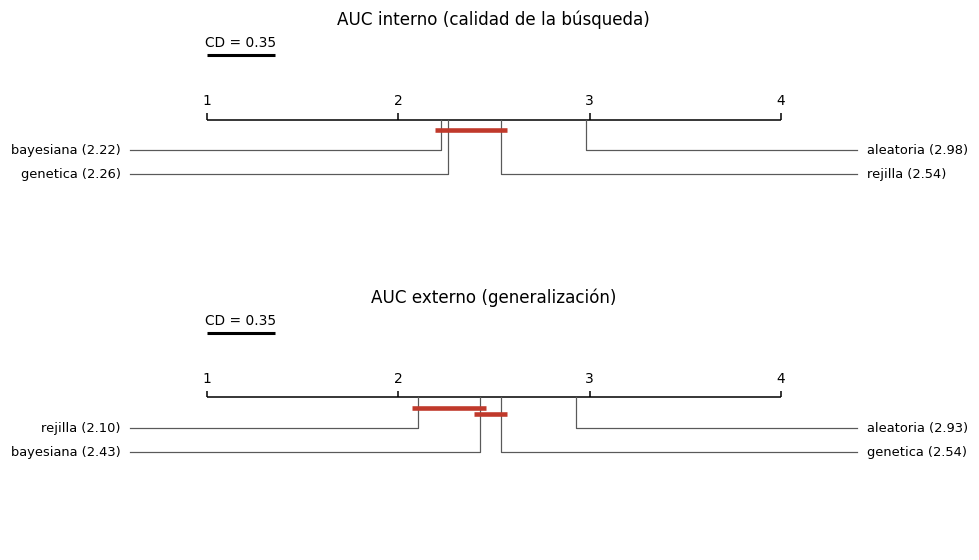

In [4]:
bloques = ["tarea", "modelo", "balanceo", "pliegue"]
resultados_friedman = {}
fig, axes = plt.subplots(2, 1, figsize=(9, 5.2))
for ax, (col, nombre) in zip(axes, [("auc_interno", "AUC interno (calidad de la búsqueda)"),
                                    ("m_auc_roc", "AUC externo (generalización)")]):
    M = pliegues.pivot_table(index=bloques, columns="optimizador", values=col)[METODOS].dropna()
    fr = est_.friedman(M)
    cd = est_.diferencia_critica(len(METODOS), len(M))
    resultados_friedman[col] = fr
    print(f"{nombre}: bloques={fr['bloques']}  chi2={fr['chi2']:.2f}  p={fr['p']:.3g}  "
          f"F_ID={fr['F_iman_davenport']:.2f} p={fr['p_F']:.3g}")
    est_.diagrama_cd(fr["rangos_medios"], cd, ax=ax, titulo=nombre)
fig.tight_layout()
graficos.guardar(fig, "04_cd_optimizadores")
plt.show()

### 2.3 Curvas de desempeño en cualquier momento

Para cada unidad, la curva es el mejor AUC interno encontrado hasta la evaluación t. Para hacer
comparables bloques con AUC distintos se usa la **brecha al mejor conocido**: la diferencia entre el
mejor AUC que cualquiera de los cuatro métodos alcanzó en ese bloque y el mejor del método hasta t.
Una curva que baja rápido es un método que encuentra buenas configuraciones con poco presupuesto.
Grid Search se representa con su orden natural de recorrido; si su rejilla tiene menos de 20 puntos,
su curva se prolonga con su último valor.

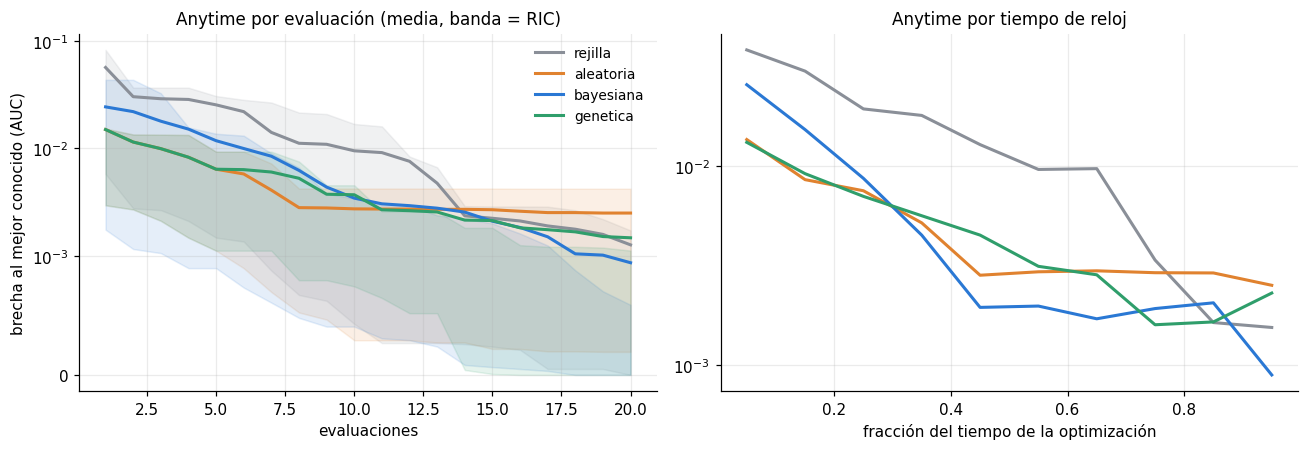

In [5]:
N = config.N_EVALUACIONES
filas = []
for r in registros:
    curva = [h["mejor"] for h in r["historial"]]
    tiempos = np.cumsum([h["segundos"] for h in r["historial"]])
    curva = (curva + [curva[-1]] * N)[:N]
    tiempos = list(tiempos) + [tiempos[-1]] * N
    for t in range(N):
        filas.append({"tarea": r["tarea"], "modelo": r["modelo"], "balanceo": r["balanceo"],
                      "pliegue": r["pliegue"], "optimizador": r["optimizador"], "t": t + 1,
                      "mejor": curva[t], "segundos": tiempos[t]})
anytime = pd.DataFrame(filas)
mejor_conocido = anytime.groupby(bloques)["mejor"].max().rename("mejor_conocido")
anytime = anytime.join(mejor_conocido, on=bloques)
anytime["brecha"] = anytime["mejor_conocido"] - anytime["mejor"]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for m in METODOS:
    a = anytime[anytime["optimizador"] == m]
    g = a.groupby("t")["brecha"]
    ax[0].plot(g.mean().index, g.mean(), label=m, color=COLOR_OPT[m], lw=2)
    ax[0].fill_between(g.mean().index, g.quantile(0.25), g.quantile(0.75),
                       color=COLOR_OPT[m], alpha=0.12)
    # misma brecha frente al tiempo de reloj acumulado (normalizado por bloque)
    a = a.assign(t_rel=a["segundos"] / a.groupby(bloques + ["optimizador"])["segundos"].transform("max"))
    b = a.groupby(pd.cut(a["t_rel"], np.linspace(0, 1, 11)), observed=True)["brecha"].mean()
    ax[1].plot(np.linspace(0.05, 0.95, len(b)), b.to_numpy(), label=m, color=COLOR_OPT[m], lw=2)
ax[0].set_yscale("symlog", linthresh=1e-3)
ax[0].set_xlabel("evaluaciones")
ax[0].set_ylabel("brecha al mejor conocido (AUC)")
ax[0].set_title("Anytime por evaluación (media, banda = RIC)")
ax[0].legend()
ax[1].set_yscale("symlog", linthresh=1e-3)
ax[1].set_xlabel("fracción del tiempo de la optimización")
ax[1].set_title("Anytime por tiempo de reloj")
fig.tight_layout()
graficos.guardar(fig, "04_anytime_estudio_completo")
plt.show()

### 2.4 Evidencia cuantitativa de eficiencia

La guía exige demostrar con cifras, no con apreciación visual, si Bayesiano o Genético son más
eficientes que Grid o Random. Se resume cada curva en tres números por bloque:

* **Área bajo la curva de brecha (ABCB)**: media de la brecha sobre t = 1..20. Integra la calidad a
  lo largo de todo el presupuesto; menor es mejor.
* **Evaluaciones hasta ε**: primera t con brecha ≤ 0.001 (21 si nunca llega).
* **Brecha final** con el presupuesto completo.

y se comparan los métodos por pares con la prueba de rangos con signo de Wilcoxon sobre los mismos
bloques, con ajuste de Holm y Benjamini-Hochberg, y el delta de Cliff como tamaño del efecto.

In [6]:
def hasta_eps(s, eps=1e-3):
    idx = np.where(s.to_numpy() <= eps)[0]
    return idx[0] + 1 if len(idx) else N + 1

por_bloque = (anytime.sort_values("t").groupby(bloques + ["optimizador"])
              .agg(ABCB=("brecha", "mean"), brecha_final=("brecha", "last"),
                   eval_hasta_eps=("brecha", hasta_eps)).reset_index())
display(por_bloque.groupby("optimizador")[["ABCB", "brecha_final", "eval_hasta_eps"]]
        .agg(["mean", "median"]).reindex(METODOS).style.format(precision=4))

pares = [("bayesiana", "aleatoria"), ("genetica", "aleatoria"), ("bayesiana", "rejilla"),
         ("genetica", "rejilla"), ("bayesiana", "genetica"), ("aleatoria", "rejilla")]
W = por_bloque.pivot_table(index=bloques, columns="optimizador", values="ABCB").dropna()
filas = []
for a, b in pares:
    w = stats.wilcoxon(W[a], W[b], zero_method="zsplit")
    d, mag = est_.delta_cliff(W[b], W[a])       # d > 0: `a` tiene menor ABCB (mejor)
    filas.append({"A": a, "B": b, "ABCB_A": W[a].mean(), "ABCB_B": W[b].mean(),
                  "A_mejor_en_%_bloques": 100 * (W[a] < W[b]).mean(),
                  "p_wilcoxon": w.pvalue, "delta_cliff": d, "magnitud": mag})
comp = pd.DataFrame(filas)
comp = pd.concat([comp, est_.ajustar_p(comp["p_wilcoxon"])[["p_holm", "p_bh"]]], axis=1)
display(comp.style.format(precision=4))
comp.to_csv(config.DIR_ESTUDIOS / "eficiencia_optimizadores.csv", index=False)

,A,B,ABCB_A,ABCB_B,A_mejor_en_%_bloques,p_wilcoxon,delta_cliff,magnitud,p_holm,p_bh
0,bayesiana,aleatoria,0.0072,0.0048,46.8571,0.0002,-0.0081,insignificante,0.0005,0.0003
1,genetica,aleatoria,0.0048,0.0048,39.4286,0.2045,-0.0338,insignificante,0.4054,0.2045
2,bayesiana,rejilla,0.0072,0.0136,70.8571,0.0000,0.3121,pequeno,0.0000,0.0000
3,genetica,rejilla,0.0048,0.0136,78.2857,0.0000,0.3800,mediano,0.0000,0.0000
4,bayesiana,genetica,0.0072,0.0048,54.2857,0.2027,0.0387,insignificante,0.4054,0.2045
5,aleatoria,rejilla,0.0048,0.0136,78.2857,0.0000,0.3881,mediano,0.0000,0.0000


**Lectura.** **Menor ABCB.** Aleatoria y genética empatan como las más eficientes (ABCB media
0.0048); la bayesiana queda en 0.0072 y la rejilla, claramente la peor, en 0.0136. La diferencia
bayesiana-aleatoria es estadísticamente detectable (Wilcoxon, p de Holm = 0.0005), pero su tamaño de
efecto es insignificante (delta de Cliff −0.008) y la bayesiana gana en el 47 % de los bloques: su
peor media viene del arranque, porque sus primeras evaluaciones son aleatorias por diseño. En cambio
es la que termina más cerca del óptimo (brecha final media 0.0009 frente a 0.0025 de la aleatoria) y
la que antes llega a 0.001 del mejor conocido (11.5 evaluaciones de media frente a 13.5). Genética y
aleatoria no se distinguen (p de Holm = 0.41).

**Frente a la rejilla.** Los otros tres métodos la superan con efecto pequeño o mediano (delta de
Cliff 0.31-0.39; mejores en el 71-78 % de los bloques; p de Holm < 0.0001). La rejilla paga dos
limitaciones de diseño: no puede ajustar su tamaño al presupuesto (17.1 evaluaciones de media, no
20) y, en espacios de 5-7 dimensiones, 20 puntos dejan 1-2 niveles por dimensión, de modo que dedica
evaluaciones a combinaciones que solo varían en hiperparámetros poco influyentes.

**Lo que no cambia.** La sección 2.2 añade el matiz decisivo: Friedman detecta diferencias entre
métodos tanto en AUC interno como en externo (p ≈ 10⁻⁸ con 175 bloques), pero en el AUC externo el
orden se invierte parcialmente —la rejilla tiene el mejor rango medio (2.10) y la aleatoria el peor
(2.93)— y las medias por método difieren en unas 0.002 (0.7103-0.7119 en clasificación), por debajo
de la desviación entre pliegues. Con 20 evaluaciones, la eficiencia de la búsqueda no se traduce en
mejor generalización.

### 2.5 Optimismo del bucle interno

El AUC interno del mejor candidato es el máximo de varias estimaciones ruidosas y está sesgado al
alza. La diferencia con el AUC externo cuantifica cuánto se habría sobreestimado el desempeño sin la
validación anidada, y si ese sesgo crece con la capacidad de búsqueda del método.

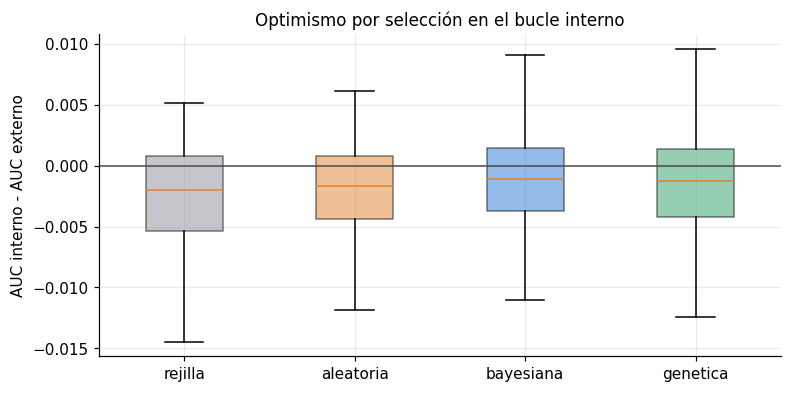

,count,mean,std,min,25%,50%,75%,max
optimizador,,,,,,,,
rejilla,175.0,-0.002950,0.005009,-0.022449,-0.005381,-0.002008,0.000819,0.005118
aleatoria,175.0,-0.002234,0.004767,-0.020359,-0.004369,-0.001681,0.000751,0.013640
bayesiana,175.0,-0.001528,0.005959,-0.022195,-0.003721,-0.001101,0.001455,0.034032
genetica,175.0,-0.001805,0.005162,-0.022449,-0.004235,-0.001231,0.001397,0.010541


In [7]:
opt_df = pliegues.assign(optimismo=pliegues["auc_interno"] - pliegues["m_auc_roc"])
fig, ax = plt.subplots(figsize=(8, 3.8))
datos_box = [opt_df.loc[opt_df["optimizador"] == m, "optimismo"] for m in METODOS]
bp = ax.boxplot(datos_box, tick_labels=METODOS, showfliers=False, patch_artist=True)
for caja, m in zip(bp["boxes"], METODOS):
    caja.set_facecolor(COLOR_OPT[m]); caja.set_alpha(0.5)
ax.axhline(0, color="0.3", lw=1)
ax.set_ylabel("AUC interno - AUC externo")
ax.set_title("Optimismo por selección en el bucle interno")
graficos.guardar(fig, "04_optimismo")
plt.show()
display(opt_df.groupby("optimizador")["optimismo"].describe().reindex(METODOS))

## 3. Estudio dedicado de convergencia

El estudio completo usa 20 evaluaciones: suficiente para comparar, corto para ver convergencia.
Aquí se toma **XGBoost sin balanceo** (el espacio de mayor dimensión, 7 hiperparámetros) y se le
da a cada método un presupuesto de 50 evaluaciones sobre la partición interna `e0/i0` (~131 mil
filas de entrenamiento y ~66 mil de validación: el conjunto completo de esa partición, sin
submuestreo), con **tres semillas por método** para medir la estabilidad de la solución encontrada
(la semilla del modelo se mantiene fija; solo varía la del optimizador). Grid Search es
determinista y se ejecuta una vez.

Cada corrida se guarda en `resultados/estudios/convergencia/`; si se interrumpe, se retoma.

In [8]:
DIR_CONV = config.DIR_ESTUDIOS / "convergencia"
DIR_CONV.mkdir(parents=True, exist_ok=True)
N_CONV = 8 if config.MODO_PRUEBA else 50
SEMILLAS_CONV = [0, 1, 2]
TAREA_C, MODELO_C, BAL_C = "clasificacion", "xgboost", "ninguno"
esp_c = espacios.espacio(TAREA_C, MODELO_C)

cache = ex.CacheParticiones()
_, internas = cache.pliegue(0)
part_c = internas[0]
Xt_c, yt_c, Xb_c, es_c = cache.entrenamiento(part_c, TAREA_C, MODELO_C, BAL_C)

def objetivo_c(params):
    return ex._evaluar_interna(TAREA_C, MODELO_C, params, BAL_C, Xt_c, yt_c, part_c.X_va,
                               part_c.y_va, config.SEMILLA, config.DISPOSITIVO_XGB,
                               Xb_c, es_c)[0]

def correr_convergencia(metodo, semilla):
    ruta = DIR_CONV / f"{metodo}_s{semilla}.json"
    if ruta.is_file():
        return json.loads(ruta.read_text(encoding="utf-8"))
    try:
        kw = {"devolver_estudio": True} if metodo == "bayesiana" else {}
        r = opt.optimizar(metodo, esp_c, objetivo_c, N_CONV, semilla=semilla, **kw)
        if metodo == "bayesiana":
            try:
                joblib.dump(r.extra.pop("estudio"), DIR_CONV / f"optuna_s{semilla}.pkl")
            except Exception as e:
                print("No se pudo guardar el estudio de Optuna:", e)
        reg = ex._json_seguro({"metodo": metodo, "semilla": semilla, "t_total": r.t_total,
                               "mejor": r.mejor_puntaje, "mejor_params": r.mejor_params,
                               "historial": r.historial, "extra": r.extra})
        ruta.write_text(json.dumps(reg), encoding="utf-8")
        print(f"  {metodo:10s} semilla {semilla}: mejor AUC {r.mejor_puntaje:.4f} "
              f"en {r.n_evaluaciones} eval, {r.t_total / 60:.1f} min", flush=True)
        return reg
    except Exception:
        traceback.print_exc()
        return None

conv = []
for m in METODOS:
    for s in (SEMILLAS_CONV[:1] if m == "rejilla" else SEMILLAS_CONV):
        r = correr_convergencia(m, s)
        if r:
            conv.append(r)
cache.liberar()
print(f"Corridas disponibles: {len(conv)}")

Corridas disponibles: 10


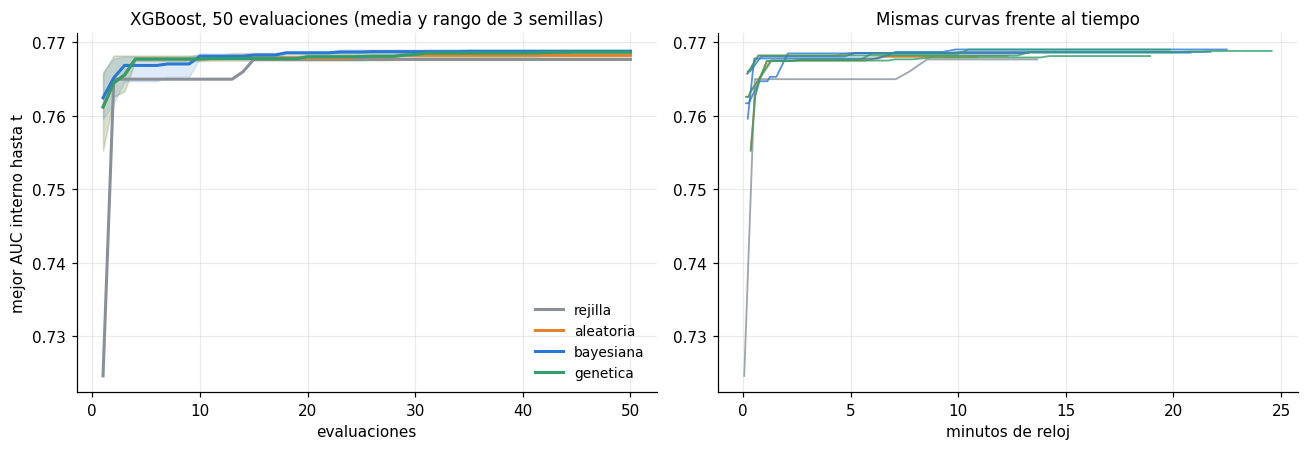

,metodo,semilla,mejor_auc,evaluaciones,eval_hasta_0.002,ABCB,minutos
0,rejilla,0,0.7677,48,15,0.0029,13.6661
1,aleatoria,0,0.7680,50,4,0.0016,10.8889
2,aleatoria,1,0.7681,50,4,0.0015,12.2975
3,aleatoria,2,0.7686,50,2,0.0006,13.2409
4,bayesiana,0,0.7686,50,10,0.0013,20.8679
5,bayesiana,1,0.7690,50,2,0.0006,22.5721
6,bayesiana,2,0.7687,50,3,0.0006,21.8116
7,genetica,0,0.7681,50,4,0.0016,18.9211
8,genetica,1,0.7690,50,4,0.0011,19.8358
9,genetica,2,0.7688,50,2,0.0006,24.5648


In [9]:
mejor_global = max(r["mejor"] for r in conv)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
filas = []
for m in METODOS:
    corr = [r for r in conv if r["metodo"] == m]
    if not corr:
        continue
    curvas = np.array([([h["mejor"] for h in r["historial"]] + [r["historial"][-1]["mejor"]] * N_CONV)[:N_CONV]
                       for r in corr])
    t = np.arange(1, N_CONV + 1)
    ax[0].plot(t, curvas.mean(0), color=COLOR_OPT[m], lw=2, label=m)
    if len(corr) > 1:
        ax[0].fill_between(t, curvas.min(0), curvas.max(0), color=COLOR_OPT[m], alpha=0.15)
    for r, c in zip(corr, curvas):
        seg = np.cumsum([h["segundos"] for h in r["historial"]]) / 60
        ax[1].plot(seg, c[:len(seg)], color=COLOR_OPT[m], lw=1.2, alpha=0.8)
        brecha = mejor_global - c
        alcanza = np.where(brecha <= 0.002)[0]
        filas.append({"metodo": m, "semilla": r["semilla"], "mejor_auc": r["mejor"],
                      "evaluaciones": len(r["historial"]),
                      "eval_hasta_0.002": int(alcanza[0] + 1) if len(alcanza) else None,
                      "ABCB": float(brecha.mean()), "minutos": r["t_total"] / 60})
ax[0].set_xlabel("evaluaciones"); ax[0].set_ylabel("mejor AUC interno hasta t")
ax[0].set_title(f"XGBoost, {N_CONV} evaluaciones (media y rango de 3 semillas)")
ax[0].legend()
ax[1].set_xlabel("minutos de reloj"); ax[1].set_title("Mismas curvas frente al tiempo")
fig.tight_layout()
graficos.guardar(fig, "04_convergencia_xgboost")
plt.show()

tabla_conv = pd.DataFrame(filas)
display(tabla_conv.style.format(precision=4))
display(tabla_conv.groupby("metodo")[["mejor_auc", "ABCB", "eval_hasta_0.002", "minutos"]]
        .agg(["mean", "std"]).reindex(METODOS).style.format(precision=4))
tabla_conv.to_csv(config.DIR_ESTUDIOS / "convergencia_xgboost.csv", index=False)

**Lectura.** Con 50 evaluaciones sobre XGBoost los cuatro métodos llegan a la misma meseta: el mejor
AUC interno va de 0.7677 (rejilla) a 0.7688 (bayesiana, media de 3 semillas), una diferencia de
0.001. Lo que los distingue es la velocidad y la estabilidad. Aleatoria y genética llegan a 0.002 del
mejor global en 3.3 evaluaciones de media, la bayesiana en 5.0 (una de sus semillas necesitó 10) y la
rejilla en 15. La bayesiana es la más estable entre semillas (desviación del mejor AUC 0.0002, frente
a 0.0003 de la aleatoria y 0.0005 de la genética), la de mejor resultado medio y la de menor ABCB
(0.0008). Ningún método muestra un estancamiento perjudicial: las curvas siguen ganando milésimas
hasta las evaluaciones 30-40. En tiempo de reloj la comparación cambia: la bayesiana y la genética
tardaron unos 21-22 minutos frente a 12 de la aleatoria, de modo que, por minuto de cómputo, la
búsqueda aleatoria es tan eficiente como cualquiera de las adaptativas.

## 4. Detalle del método Bayesiano

### 4.1 Historial de la optimización e importancia de hiperparámetros

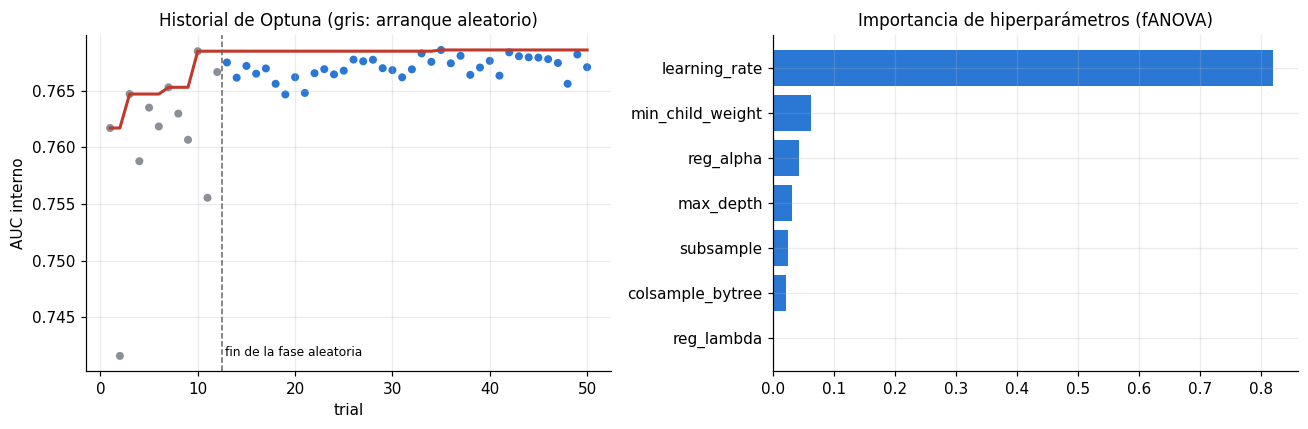

In [10]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
ruta_estudio = DIR_CONV / "optuna_s0.pkl"
estudio = joblib.load(ruta_estudio) if ruta_estudio.is_file() else None
if estudio is not None:
    trials = [t for t in estudio.trials if t.value is not None]
    vals = np.array([t.value for t in trials])
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    n_arr = max(3, N_CONV // 4)
    ax[0].scatter(range(1, len(vals) + 1), vals, s=18,
                  c=["#8a8f98" if i < n_arr else "#2a78d4" for i in range(len(vals))])
    ax[0].plot(range(1, len(vals) + 1), np.maximum.accumulate(vals), color="#c0392b", lw=2)
    ax[0].axvline(n_arr + 0.5, color="0.4", ls="--", lw=1)
    ax[0].text(n_arr + 0.8, vals.min(), "fin de la fase aleatoria", fontsize=8)
    ax[0].set_xlabel("trial"); ax[0].set_ylabel("AUC interno")
    ax[0].set_title("Historial de Optuna (gris: arranque aleatorio)")
    try:
        imp = optuna.importance.get_param_importances(estudio)
        ax[1].barh(list(imp)[::-1], list(imp.values())[::-1], color="#2a78d4")
        ax[1].set_title("Importancia de hiperparámetros (fANOVA)")
    except Exception as e:
        ax[1].text(0.1, 0.5, f"No disponible: {e}", fontsize=8)
    fig.tight_layout()
    graficos.guardar(fig, "04_optuna_historial")
    plt.show()
else:
    print("No hay estudio de Optuna guardado (ver sección 3).")

### 4.2 El modelo sustituto del TPE

Para `learning_rate` (en escala log) se reconstruyen las dos densidades del TPE con los trials del
estudio: l(x) con el mejor cuantil γ (el mismo γ(n) = min(⌈0.1 n⌉, 25) que usa Optuna) y g(x) con
el resto. El cociente l(x)/g(x) es proporcional a la Mejora Esperada: el TPE propone donde es
máximo. Es la "superficie de la función sustituta" que sugiere la guía, en la forma que corresponde
a este sustituto.

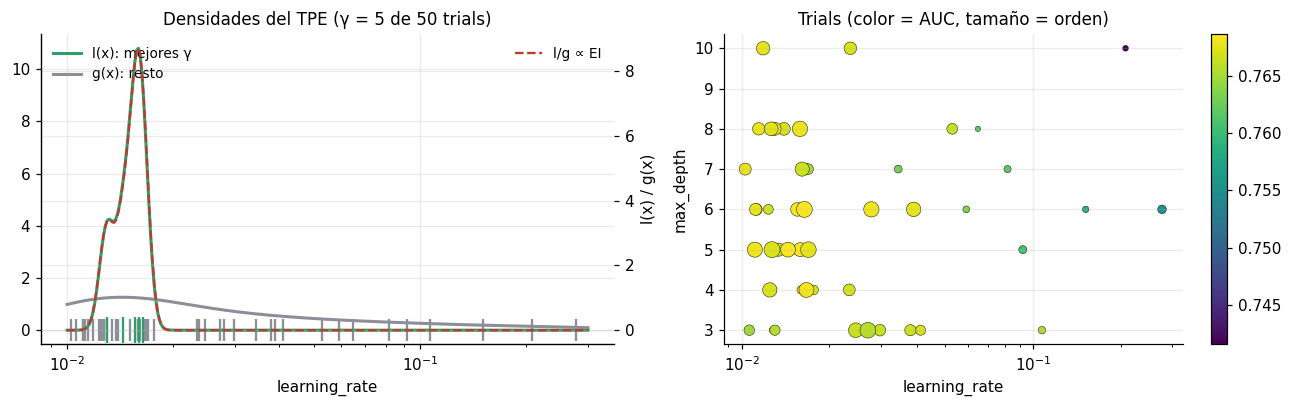

In [11]:
if estudio is not None:
    n = len(trials)
    gamma = min(int(np.ceil(0.1 * n)), 25)
    orden = np.argsort(-vals)
    buenos, malos = orden[:gamma], orden[gamma:]
    x = np.log10([t.params["learning_rate"] for t in trials])
    malla = np.linspace(np.log10(0.01), np.log10(0.3), 300)
    l = stats.gaussian_kde(x[buenos], bw_method=0.5)(malla) if len(buenos) > 1 else np.ones_like(malla)
    g = stats.gaussian_kde(x[malos], bw_method=0.5)(malla)
    fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
    ax[0].plot(10 ** malla, l, label="l(x): mejores γ", color="#2f9e6b", lw=2)
    ax[0].plot(10 ** malla, g, label="g(x): resto", color="#8a8f98", lw=2)
    ax[0].scatter(10 ** x[malos], np.zeros(len(malos)), marker="|", color="#8a8f98", s=200)
    ax[0].scatter(10 ** x[buenos], np.zeros(len(buenos)), marker="|", color="#2f9e6b", s=300)
    ax2 = ax[0].twinx()
    ax2.plot(10 ** malla, l / g, color="#c0392b", lw=1.5, ls="--", label="l/g ∝ EI")
    ax2.set_ylabel("l(x) / g(x)")
    ax[0].set_xscale("log"); ax[0].set_xlabel("learning_rate")
    ax[0].set_title(f"Densidades del TPE (γ = {gamma} de {n} trials)")
    ax[0].legend(loc="upper left"); ax2.legend(loc="upper right")
    md_ = np.array([t.params["max_depth"] for t in trials])
    sc = ax[1].scatter([t.params["learning_rate"] for t in trials], md_, c=vals, cmap="viridis",
                       s=[12 + 2 * i for i in range(n)], edgecolor="k", lw=0.3)
    ax[1].set_xscale("log"); ax[1].set_xlabel("learning_rate"); ax[1].set_ylabel("max_depth")
    ax[1].set_title("Trials (color = AUC, tamaño = orden)")
    fig.colorbar(sc, ax=ax[1])
    fig.tight_layout()
    graficos.guardar(fig, "04_tpe_sustituto")
    plt.show()

## 5. Detalle del método Genético: diversidad y convergencia prematura

La diversidad genética es la distancia euclídea media entre pares de genomas, normalizada por √d
(0 = todos los individuos idénticos). Si cae a cero mientras la mejor aptitud sigue lejos del
óptimo conocido, la población convergió prematuramente: la selección eliminó la variabilidad antes
de encontrar la región buena, y a partir de ahí solo la mutación puede explorar.

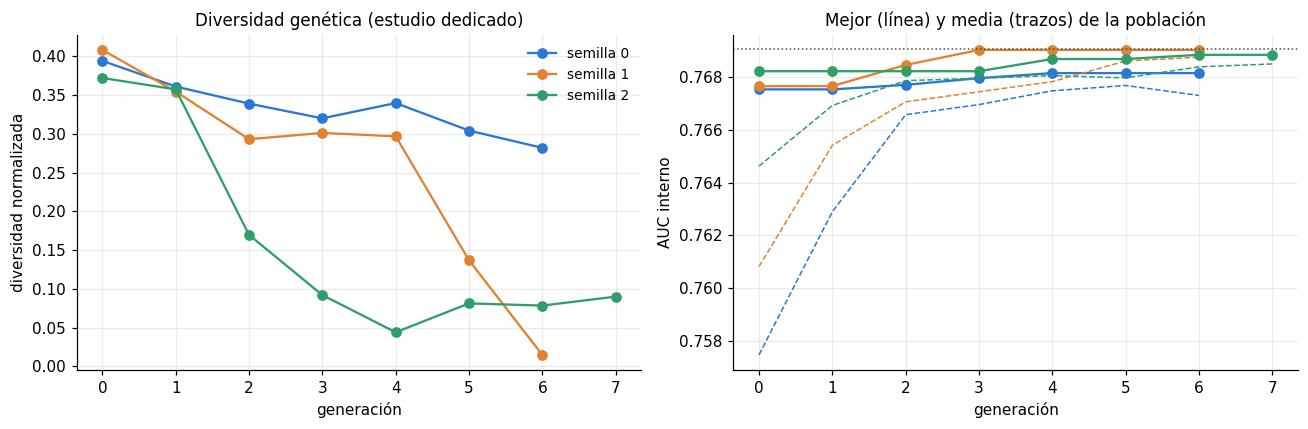

,diversidad,mejor,media
generacion,,,
0,0.3900,0.7063,0.6950
1,0.2781,0.7074,0.7009
2,0.1359,0.7090,0.7064
3,0.1116,0.7103,0.7081
4,0.0649,0.7104,0.7095
5,0.0471,0.7095,0.7089
6,0.0726,0.7045,0.7031
7,0.0658,0.6993,0.6983
8,0.0329,0.7106,0.7101


In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for r in [r for r in conv if r["metodo"] == "genetica"]:
    g = pd.DataFrame(r["extra"]["generaciones"])
    ax[0].plot(g["generacion"], g["diversidad"], marker="o", lw=1.5, label=f"semilla {r['semilla']}")
    ax[1].plot(g["generacion"], g["mejor"], marker="o", lw=1.5, label=f"mejor, s{r['semilla']}")
    ax[1].plot(g["generacion"], g["media"], ls="--", lw=1, color=ax[1].lines[-1].get_color())
ax[0].set_xlabel("generación"); ax[0].set_ylabel("diversidad normalizada")
ax[0].set_title("Diversidad genética (estudio dedicado)"); ax[0].legend()
ax[1].axhline(mejor_global, color="0.3", ls=":", lw=1)
ax[1].set_xlabel("generación"); ax[1].set_ylabel("AUC interno")
ax[1].set_title("Mejor (línea) y media (trazos) de la población")
fig.tight_layout()
graficos.guardar(fig, "04_genetico_diversidad")
plt.show()

# diversidad en el estudio completo (todas las unidades con optimizador genético)
gens = []
for r in registros:
    if r["optimizador"] == "genetica":
        for g in r["extra"].get("generaciones", []):
            gens.append({"modelo": r["modelo"], **g})
gens = pd.DataFrame(gens)
if len(gens):
    display(gens.groupby("generacion")[["diversidad", "mejor", "media"]].mean().style.format(precision=4))

**Lectura.** En el estudio dedicado, la diversidad cae por debajo de 0.1 en dos de las tres
semillas: en la semilla 2 en la generación 3 y en la semilla 1 en la generación 6; la semilla 0 la
mantiene cerca de 0.28 hasta el final. El colapso no coincide con el estancamiento. La semilla 1
alcanzó su mejor aptitud (0.7690, la mejor de todo el estudio de convergencia) en la generación 3,
cuando su diversidad aún era de 0.30, y la semilla 2 siguió mejorando en las generaciones 4-6 con
diversidad baja, gracias a la mutación y al elitismo. Con una población de 5 individuos la
convergencia es rápida por construcción, pero aquí no fue prematura en el sentido dañino: las tres
semillas terminan a menos de 0.001 del mejor global. La tabla del estudio completo, que promedia
todas las unidades con optimizador genético, muestra la misma caída temprana (de 0.39 en la
generación 0 a 0.11 en la 3 y por debajo de 0.1 desde la 4). Sus valores de aptitud en las
generaciones altas no son comparables entre sí, porque cada generación promedia un conjunto distinto
de unidades: solo las que llegaron a tantas generaciones.

## 6. Successive Halving (multi-fidelidad)

Se muestrean 27 configuraciones de XGBoost y se evalúan con **1/27 del entrenamiento** de `e0/i0`
(~4,900 filas); sobrevive el mejor tercio, que se evalúa con 1/9, luego 1/3 y finalmente con el
**entrenamiento completo** la última configuración (η = 3; 4 rondas). La validación es siempre la
partición interna completa.

* **Métrica de fidelidad: fracción del entrenamiento.** El coste de XGBoost `hist` es lineal en n,
  de modo que la fidelidad se traduce directamente en coste; y el ordenamiento relativo de
  configuraciones suele conservarse con muestras grandes (1/27 aquí son casi 5 mil filas con ~400
  positivos). La alternativa, fidelidad = número de árboles, interactúa con la parada temprana.
* **Factor de reducción η = 3**: el de Hyperband. Con η = 2 harían falta más rondas y más coste; con
  η mayor se descartan configuraciones con evidencia de fidelidad muy baja.
* **Coste total**: 27·(1/27) + 9·(1/9) + 3·(1/3) + 1·1 = **4 entrenamientos completos equivalentes**,
  frente a 27 de evaluar todas con fidelidad completa. Se compara con Random Search del estudio de
  convergencia (mismo espacio, misma partición) con 4 y 27 evaluaciones.

Nota sobre "no submuestrear": las fracciones pequeñas solo sirven para *descartar*; la configuración
elegida siempre se evalúa con el entrenamiento completo.

In [13]:
ruta_sh = config.DIR_ESTUDIOS / "successive_halving.json"
if ruta_sh.is_file():
    sh = json.loads(ruta_sh.read_text(encoding="utf-8"))
else:
    cache = ex.CacheParticiones()
    _, internas = cache.pliegue(0)
    p = internas[0]
    Xt, yt, _, es = cache.entrenamiento(p, TAREA_C, MODELO_C, BAL_C)
    y_np = np.asarray(yt)

    def objetivo_fidelidad(params, fid):
        if fid < 1:
            idx, _ = train_test_split(np.arange(len(y_np)), train_size=fid, stratify=y_np,
                                      random_state=config.SEMILLA)
            idx.sort()
            X, y = np.asarray(Xt[idx]), y_np[idx]
        else:
            X, y = Xt, y_np
        est, _ = mod.entrenar(TAREA_C, MODELO_C, params, BAL_C, X, y, es=es)
        return roc_auc_score(np.asarray(p.y_va), mod.puntuar(est, p.X_va, TAREA_C))

    n0 = 9 if config.MODO_PRUEBA else 27
    t0 = time.perf_counter()
    mejor_sh, registro_sh = opt.mitades_sucesivas(esp_c, objetivo_fidelidad, n_inicial=n0, eta=3)
    sh = ex._json_seguro({"mejor_params": mejor_sh, "rondas": registro_sh,
                          "t_total": time.perf_counter() - t0,
                          "auc_final": registro_sh[-1]["mejor"]})
    ruta_sh.write_text(json.dumps(sh), encoding="utf-8")
    cache.liberar()

rondas = pd.DataFrame(sh["rondas"])
display(rondas.style.format(precision=4))
coste_sh = rondas["coste_equivalente"].sum()
aleat = [r for r in conv if r["metodo"] == "aleatoria"]
comp_sh = [{"estrategia": "Successive Halving", "coste (entrenamientos completos)": coste_sh,
            "AUC": sh["auc_final"], "minutos": sh["t_total"] / 60}]
for k in (int(round(coste_sh)), 27):
    if aleat and k <= N_CONV:
        v = [max(h["puntaje"] for h in r["historial"][:k]) for r in aleat]
        s = [sum(h["segundos"] for h in r["historial"][:k]) / 60 for r in aleat]
        comp_sh.append({"estrategia": f"Random Search, {k} evaluaciones (media de 3 semillas)",
                        "coste (entrenamientos completos)": k, "AUC": np.mean(v),
                        "minutos": np.mean(s)})
display(pd.DataFrame(comp_sh).style.format(precision=4))

,ronda,configuraciones,fidelidad,coste_equivalente,mejor,segundos
0,0,27,0.0370,1.0000,0.7243,60.7042
1,1,9,0.1111,1.0000,0.7436,37.8762
2,2,3,0.3333,1.0000,0.7584,23.8926
3,3,1,1.0000,1.0000,0.7662,17.7233


,estrategia,coste (entrenamientos completos),AUC,minutos
0,Successive Halving,4.0000,0.7662,2.3366
1,"Random Search, 4 evaluaciones (media de 3 semillas)",4.0000,0.7677,1.1607
2,"Random Search, 27 evaluaciones (media de 3 semillas)",27.0000,0.7681,7.1876


## 7. Verificación: preprocesamiento en caché frente a `Pipeline`

El estudio ajusta imputación, escalado y codificación una vez por partición y reutiliza el
resultado. Se comprueba que eso da **el mismo AUC** que un `Pipeline` de imbalanced-learn que
reajusta preprocesamiento + SMOTE + modelo desde los datos crudos, como haría `GridSearchCV`. Se usa
la regresión logística L2 con `C = 0.01` y SMOTE en la partición `e0/i0`. Ambos caminos operan en
float32, de modo que la diferencia esperada es del orden del redondeo numérico.

In [14]:
ruta_ver = config.DIR_ESTUDIOS / "verificacion_pipeline.json"
if ruta_ver.is_file():
    ver = json.loads(ruta_ver.read_text(encoding="utf-8"))
else:
    from imblearn.pipeline import Pipeline as PipelineImb
    from imblearn.over_sampling import SMOTE
    from sklearn.preprocessing import FunctionTransformer

    conj = datos.cargar_traspaso()
    y_all = conj.y_dev.to_numpy()
    tr, _ = prep.pliegues_externos(y_all)[0]
    itr, iva = prep.pliegues_internos(y_all[tr], 0)[0]
    X_ext, y_ext = conj.X_dev.iloc[tr], y_all[tr]
    params = {"C": 0.01, "penalizacion": "l2"}

    def a_float32(X):
        return np.asarray(X, dtype=np.float32)

    pipe = PipelineImb([
        ("pre", prep.construir_preprocesador(conj.cuantitativas, conj.cualitativas)),
        ("f32", FunctionTransformer(a_float32)),
        ("smote", SMOTE(sampling_strategy=config.SMOTE_PROPORCION, k_neighbors=5,
                        random_state=config.SEMILLA)),
        ("modelo", mod.construir("clasificacion", "logistica", params, "smote"))])
    t0 = time.perf_counter()
    pipe.fit(X_ext.iloc[itr], y_ext[itr])
    auc_pipe = roc_auc_score(y_ext[iva], pipe.predict_proba(X_ext.iloc[iva])[:, 1])
    t_pipe = time.perf_counter() - t0
    del conj

    cache = ex.CacheParticiones()
    _, internas = cache.pliegue(0)
    p = internas[0]
    Xt, yt, Xb, es = cache.entrenamiento(p, "clasificacion", "logistica", "smote")
    t0 = time.perf_counter()
    auc_cache = ex._evaluar_interna("clasificacion", "logistica", params, "smote", Xt, yt,
                                    p.X_va, p.y_va, config.SEMILLA, "cpu", Xb, es)[0]
    t_cache = time.perf_counter() - t0
    cache.liberar()
    ver = {"auc_pipeline": auc_pipe, "auc_cache": auc_cache,
           "diferencia": abs(auc_pipe - auc_cache), "s_pipeline": t_pipe, "s_cache": t_cache}
    ruta_ver.write_text(json.dumps(ver), encoding="utf-8")
print(f"AUC con Pipeline reajustado : {ver['auc_pipeline']:.6f}  ({ver['s_pipeline']:.1f} s)")
print(f"AUC con preprocesamiento en cache: {ver['auc_cache']:.6f}  ({ver['s_cache']:.1f} s)")
print(f"Diferencia absoluta: {ver['diferencia']:.2e}")

AUC con Pipeline reajustado : 0.736681  (19.5 s)
AUC con preprocesamiento en cache: 0.736681  (6.3 s)
Diferencia absoluta: 0.00e+00


## 8. Conclusiones del capítulo

1. **Calidad por evaluación.** Aleatoria y genética son las más eficientes por área bajo la curva de
   brecha (ABCB 0.0048) y la bayesiana la que termina más cerca del óptimo (brecha final 0.0009).
   Entre las tres, las diferencias son detectables en algún par pero de tamaño insignificante (delta
   de Cliff ≤ 0.04). La rejilla es claramente inferior (efecto pequeño a mediano frente a las otras
   tres) y ni siquiera usa todo el presupuesto (17.1 evaluaciones de media).
2. **Efecto en el AUC externo.** Ninguno relevante. Friedman detecta diferencias entre métodos (p ≈
   10⁻⁸ con 175 bloques), pero las medias de AUC externo por método difieren en ~0.002 y el orden
   incluso se invierte (la rejilla tiene el mejor rango medio). Con 20 evaluaciones, todos los métodos
   encuentran configuraciones que están dentro del ruido de la mejor.
3. **Optimismo.** El AUC interno del ganador es en media *menor* que el externo (entre −0.0015 y
   −0.003 según el método): los modelos internos se entrenan con dos tercios del entrenamiento
   externo, y ese efecto de tamaño de muestra supera al sesgo de selección del máximo. En este estudio
   la validación anidada no corrige un optimismo, sino un ligero pesimismo.
4. **Estabilidad.** En el estudio dedicado (50 evaluaciones, 3 semillas) la bayesiana es la más
   estable (desviación 0.0002) y la de mejor resultado medio (0.7688), pero todas alcanzan la misma
   meseta y, por minuto de cómputo, la búsqueda aleatoria es tan eficiente como las adaptativas.
5. **Genético.** La diversidad cae por debajo de 0.1 en dos de las tres semillas sin que eso produzca
   un estancamiento perjudicial; con una población de 5 la búsqueda se comporta como una búsqueda
   local con reinicios por mutación.
6. **Successive Halving.** Con un coste de 4 entrenamientos completos alcanzó 0.7662, peor que Random
   Search con el mismo coste (0.7677) o con 27 evaluaciones (0.7681), y tardó el doble que la
   aleatoria de 4 evaluaciones (2.3 frente a 1.2 minutos). Con una fidelidad mínima de ~4,900 filas el
   orden de las configuraciones de XGBoost no se conserva: lo que funciona con pocos datos no es lo
   que funciona con todos. La multifidelidad necesita una fidelidad baja que preserve el ranking.
7. **Verificación.** El preprocesamiento en caché da exactamente el mismo AUC que el `Pipeline`
   reajustado (diferencia 0) en un tercio del tiempo (6.3 frente a 19.5 s): la caché ahorra cómputo
   sin introducir fuga de información.